# Data Cleaning & Model Training — Terrains Vente Marrakech


##  Imports


In [1]:
import os
import sys
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')

# Ajouter le dossier pipeline au path
sys.path.append(os.path.abspath('../../pipeline'))

print(' Imports OK')

 Imports OK


## 1. Chargement du fichier brut


In [2]:
RAW_PATH   = '../../data/marrakech_immo_vente/terrain_vente.csv'
CLEAN_PATH = '../../data/cleaned_data/vente/terrain_vente_final.csv'
MODEL_PATH = '../../model_training/models/xgb_terrain_vente.pkl'
META_PATH  = '../../model_training/models/xgb_terrain_vente_metadata.json'

df_raw = pd.read_csv(RAW_PATH)
print(f'Shape initiale : {df_raw.shape}')
print(f'Colonnes : {df_raw.columns.tolist()}')
df_raw.head(3)

Shape initiale : (3596, 34)
Colonnes : ['id', 'titre', 'prix', 'localisation', 'type_bien', 'surface', 'chambres', 'salles_bain', 'description', 'agence', 'url', 'source', 'piscine', 'parking', 'ascenseur', 'terrasse', 'jardin', 'climatisation', 'securite', 'vue', 'meuble', 'neuf', 'cave', 'hammam', 'etage', 'surface_terrain', 'prix_num', 'surface_num', 'chambres_num', 'salles_bain_num', 'nb_pieces', 'quartier', 'prix_m2', 'prix_m2_median_quartier']


,id,titre,prix,localisation,type_bien,surface,chambres,salles_bain,description,agence,...,etage,surface_terrain,prix_num,surface_num,chambres_num,salles_bain_num,nb_pieces,quartier,prix_m2,prix_m2_median_quartier
0,8317724.0,Beau terrain à la vente à Hay Targa. Surface t...,Prix à consulter,"Hay Targa, Marrakech",Maison,695 m²,NaN,NaN,NaN,Particulier,...,-1,NaN,NaN,695.0,0.0,0.0,1.0,Targa,NaN,4229.885057
1,7268425.0,Zone immeuble R5 plien Gueliz,Prix à consulter,"Guéliz, Marrakech",Maison,1900 m²,2 Chambres,NaN,NaN,Particulier,...,-1,NaN,NaN,1900.0,2.0,0.0,3.0,Guéliz,NaN,9000.000000
2,8238050.0,Terrain à vendre à Route de l'Ourika. Surface ...,1 700 000 DH,"Route de l'Ourika, Marrakech",Maison,500 m²,NaN,NaN,NaN,Particulier,...,-1,NaN,1700000.0,500.0,0.0,0.0,1.0,Route d'Ourika,3400.0,800.000000


## 2. Filtrage type de bien


In [3]:
# Garder uniquement les terrains
TERRAIN_TYPES = ['Terrain', 'Vente Terrain']
before = len(df_raw)
df = df_raw[df_raw['type_bien'].isin(TERRAIN_TYPES)].copy()
print(f'Conservés (terrain) : {len(df)} / {before} lignes')
print(f'Répartition types   : {df["type_bien"].value_counts().to_dict()}')

Conservés (terrain) : 2259 / 3596 lignes
Répartition types   : {'Terrain': 2146, 'Vente Terrain': 113}


## 3. Cleaning

Étapes appliquées :
1. Conversion EUR → MAD
2. Suppression lignes sans target (prix_num)
3. Filtrage surface aberrante
4. Filtrage prix/m² aberrant (seuils adaptés terrain)
5. Suppression outliers prix (percentile 1–99 sur log-échelle)
6. Nettoyage colonnes annexes


In [4]:
EUR_TO_MAD = 10.8

# 1. Conversion EUR → MAD
eur_mask = df['prix'].str.contains('EUR', na=False)
df.loc[eur_mask, 'prix_num'] = df.loc[eur_mask, 'prix_num'] * EUR_TO_MAD
print(f'EUR → MAD convertis : {eur_mask.sum()} lignes')

# 2. Suppression lignes sans target
before = len(df)
df = df[df['prix_num'].notna() & (df['prix_num'] > 0)].copy()
print(f'Supprimés (prix null/zero)     : {before - len(df)}')

# 3. Filtrage surface aberrante — seuils adaptés terrain (50 m² à 500 000 m²)
before = len(df)
df = df[df['surface_num'].notna() & (df['surface_num'] >= 50) & (df['surface_num'] <= 500_000)].copy()
print(f'Supprimés (surface aberrante)  : {before - len(df)}')

# 4. Filtrage prix/m² aberrant — seuils terrain Marrakech (50 à 50 000 MAD/m²)
df['_prix_m2'] = df['prix_num'] / df['surface_num']
before = len(df)
df = df[(df['_prix_m2'] >= 50) & (df['_prix_m2'] <= 50_000)].copy()
print(f'Supprimés (prix/m² aberrant)   : {before - len(df)}')
df.drop(columns=['_prix_m2'], inplace=True)

# 5. Outliers prix (log-échelle, percentile 1-99)
log_prix = np.log(df['prix_num'])
before = len(df)
df = df[(log_prix >= log_prix.quantile(0.01)) & (log_prix <= log_prix.quantile(0.99))].copy()
print(f'Supprimés (outliers prix)      : {before - len(df)}')

# 6. Nettoyage etage (inutile pour terrain, on force à 0)
df['etage'] = 0
df['etage_known'] = 0

# 7. Chambres / salles bain : non pertinents pour terrain → forcer à 0
df['chambres_num']   = 0
df['salles_bain_num'] = 0

print(f'\n Shape après cleaning : {df.shape}')
print(f'   Valeurs manquantes   : {df.isnull().sum().sum()}')

EUR → MAD convertis : 0 lignes
Supprimés (prix null/zero)     : 581
Supprimés (surface aberrante)  : 252
Supprimés (prix/m² aberrant)   : 156
Supprimés (outliers prix)      : 23

 Shape après cleaning : (1247, 35)
   Valeurs manquantes   : 5885


## 4. Feature Engineering


In [5]:
# ── Quartier clean (top quartiers + Autre) ────────────────────────────────
top_quartiers = df['quartier'].value_counts().index[:10]
df['quartier_clean'] = df['quartier'].apply(lambda x: x if x in top_quartiers else 'Autre')
print(f'Quartiers retenus : {df["quartier_clean"].nunique()}')
print(df['quartier_clean'].value_counts())

# ── Features numériques dérivées ──────────────────────────────────────────

# Prix médian par quartier (signal territorial fort pour terrain)
q_median = df.groupby('quartier_clean')['prix_num'].transform('median')
df['prix_median_quartier'] = q_median

# Prix/m² moyen quartier
q_pm2_mean = df.groupby('quartier_clean').apply(
    lambda g: (g['prix_num'] / g['surface_num']).mean()
).rename('pm2_mean_q')
df = df.join(q_pm2_mean, on='quartier_clean')
df.rename(columns={'pm2_mean_q': 'prix_m2_moy_quartier'}, inplace=True)

# Surface relative au quartier (terrain grand vs petit dans son quartier)
q_surf_mean = df.groupby('quartier_clean')['surface_num'].transform('mean')
df['surface_relative'] = df['surface_num'] / q_surf_mean

# Interaction surface × prix médian quartier (valeur potentielle brute)
df['surface_x_quartier'] = df['surface_num'] * q_median / 1e6

# Log surface (distribution très étalée pour terrains)
df['log_surface'] = np.log1p(df['surface_num'])

# Palier surface (catégorie taille terrain)
df['palier_surface'] = pd.cut(
    df['surface_num'],
    bins=[0, 200, 500, 1000, 5000, 20000, np.inf],
    labels=[0, 1, 2, 3, 4, 5]
).astype(int)

# Score équipements pertinents pour terrain
terrain_equip = ['piscine', 'jardin', 'securite', 'vue', 'parking']
df['score_terrain'] = df[terrain_equip].sum(axis=1)

# Nb total équipements
all_equip = ['piscine','parking','ascenseur','terrasse','jardin',
             'climatisation','securite','vue','cave','hammam']
df['nb_equipements'] = df[all_equip].sum(axis=1)

# Score standing général
df['score_standing'] = df[['piscine','terrasse','vue','hammam','climatisation','securite']].sum(axis=1)

# surface_par_chambre : non pertinent pour terrain → surface elle-même
df['surface_par_chambre'] = df['surface_num']

# Target log-transformé
df['log_prix'] = np.log(df['prix_num'])

print(f'\n Shape finale : {df.shape}')
print(f'   Nouvelles features : prix_median_quartier, prix_m2_moy_quartier, surface_relative,')
print(f'                        surface_x_quartier, log_surface, palier_surface, score_terrain')

Quartiers retenus : 10
quartier_clean
Autre                  645
Route d'Ourika         199
Route de Fès           137
Route de Casablanca    129
Targa                   52
Palmeraie               24
Guéliz                  21
Agdal                   20
Médina                  11
Hivernage                9
Name: count, dtype: int64

 Shape finale : (1247, 47)
   Nouvelles features : prix_median_quartier, prix_m2_moy_quartier, surface_relative,
                        surface_x_quartier, log_surface, palier_surface, score_terrain


## 5. Visualisation rapide


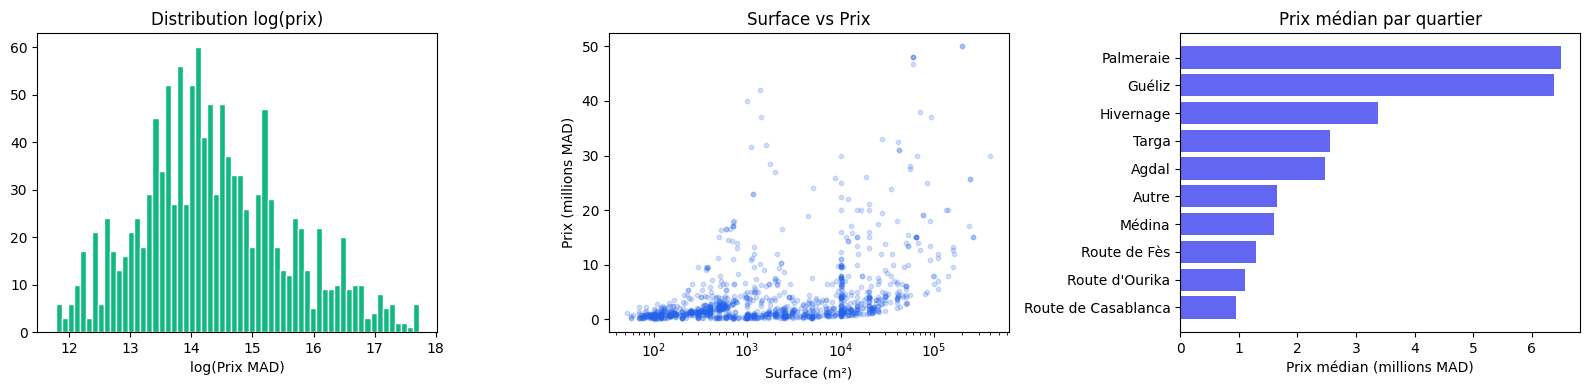


Prix médian par quartier :
                     Médiane (MAD)    N
quartier_clean                         
Palmeraie                6500000.0   24
Guéliz                   6375000.0   21
Hivernage                3380000.0    9
Targa                    2550000.0   52
Agdal                    2472000.0   20
Autre                    1650000.0  645
Médina                   1600000.0   11
Route de Fès             1300000.0  137
Route d'Ourika           1100000.0  199
Route de Casablanca       960000.0  129


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution log(prix)
axes[0].hist(df['log_prix'], bins=60, color='#10B981', edgecolor='white')
axes[0].set_title('Distribution log(prix)')
axes[0].set_xlabel('log(Prix MAD)')

# Surface vs Prix
axes[1].scatter(df['surface_num'], df['prix_num']/1e6, alpha=0.2, s=10, color='#2563EB')
axes[1].set_xlabel('Surface (m²)')
axes[1].set_ylabel('Prix (millions MAD)')
axes[1].set_title('Surface vs Prix')
axes[1].set_xscale('log')

# Prix médian par quartier
med = df.groupby('quartier_clean')['prix_num'].median().sort_values(ascending=True) / 1e6
axes[2].barh(med.index, med.values, color='#6366F1')
axes[2].set_xlabel('Prix médian (millions MAD)')
axes[2].set_title('Prix médian par quartier')

plt.tight_layout()
plt.show()

print('\nPrix médian par quartier :')
print(df.groupby('quartier_clean')['prix_num']
        .agg(['median','count'])
        .sort_values('median', ascending=False)
        .rename(columns={'median':'Médiane (MAD)','count':'N'}))

## 6. Séparation features / target + train/test split


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

NUMERIC_FEATURES = [
    'surface_num',
    'log_surface',
    'palier_surface',
    'surface_relative',
    'surface_x_quartier',
    'prix_m2_moy_quartier',
    'prix_median_quartier',
    'score_terrain',
    'score_standing',
    'nb_equipements',
    # maintenu pour compatibilité pipeline .py
    'chambres_num',
    'salles_bain_num',
    'etage',
    'etage_known',
    'surface_par_chambre',
]

BINARY_FEATURES = [
    'piscine','parking','jardin','securite','vue',
    'terrasse','neuf','meuble','climatisation','hammam','cave','ascenseur',
]

CATEGORICAL_FEATURES = ['quartier_clean']

TARGET_LOG = 'log_prix'

all_features = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
X = df[all_features].copy()
y = df[TARGET_LOG].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f' Split effectué')
print(f'   Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')
print(f'   Features : {X.shape[1]}')

 Split effectué
   Train : 997 lignes | Test : 250 lignes
   Features : 28


## 7. Preprocessor sklearn


In [8]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                            NUMERIC_FEATURES),
    ('bin', 'passthrough',                                               BINARY_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
], remainder='drop')

# Fit sur X_train uniquement (évite le data leakage)
preprocessor.fit(X_train)
print('✅ Preprocessor fitté sur X_train')

✅ Preprocessor fitté sur X_train


## 8. Optimisation des hyperparamètres avec Optuna



In [9]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 4, 9),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma'           : trial.suggest_float('gamma', 0, 3),
    }
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(**params, random_state=42, n_jobs=-1)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\n🏆 Meilleur R² CV : {study.best_value:.4f}')
print('Meilleurs hyperparamètres :')
for k, v in study.best_params.items():
    print(f'  {k:25s} : {v}')

Best trial: 83. Best value: 0.488596: 100%|██████████| 100/100 [00:41<00:00,  2.40it/s]


🏆 Meilleur R² CV : 0.4886
Meilleurs hyperparamètres :
  n_estimators              : 1067
  learning_rate             : 0.006283130387556863
  max_depth                 : 7
  subsample                 : 0.7322030716208178
  colsample_bytree          : 0.7853851519280007
  min_child_weight          : 3
  reg_alpha                 : 0.011166599575914544
  reg_lambda                : 0.03828308283030621
  gamma                     : 1.1953995578046421


## 9. Entraînement du modèle final


In [10]:
pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)),
])
pipeline_final.fit(X_train, y_train)
print(' Modèle entraîné')

 Modèle entraîné


## 10. Évaluation


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

log_pred   = pipeline_final.predict(X_test)
y_pred_mad = np.exp(log_pred)
y_true_mad = np.exp(y_test.values)

mae  = mean_absolute_error(y_true_mad, y_pred_mad)
rmse = np.sqrt(mean_squared_error(y_true_mad, y_pred_mad))
r2   = r2_score(y_true_mad, y_pred_mad)
mape = np.mean(np.abs((y_true_mad - y_pred_mad) / y_true_mad)) * 100

kf    = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(pipeline_final, X_train, y_train, cv=kf, scoring='r2')

print('\n' + '═' * 45)
print('  MÉTRIQUES D\'ÉVALUATION — TERRAIN')
print('═' * 45)
print(f'  MAE              : {mae:>15,.0f} MAD')
print(f'  RMSE             : {rmse:>15,.0f} MAD')
print(f'  R²               : {r2:>15.4f}')
print(f'  MAPE             : {mape:>14.2f} %')
print(f'  CV R² (5 folds)  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print('═' * 45)

metrics_final = {
    'R²': r2, 'MAE (MAD)': mae, 'RMSE (MAD)': rmse, 'MAPE (%)': mape,
    'CV R² (mean)': cv_r2.mean(), 'CV R² (std)': cv_r2.std(),
}


═════════════════════════════════════════════
  MÉTRIQUES D'ÉVALUATION — TERRAIN
═════════════════════════════════════════════
  MAE              :       2,847,467 MAD
  RMSE             :       6,724,487 MAD
  R²               :          0.2220
  MAPE             :          91.92 %
  CV R² (5 folds)  : 0.4783 ± 0.0525
═════════════════════════════════════════════


## 11. Visualisations du modèle


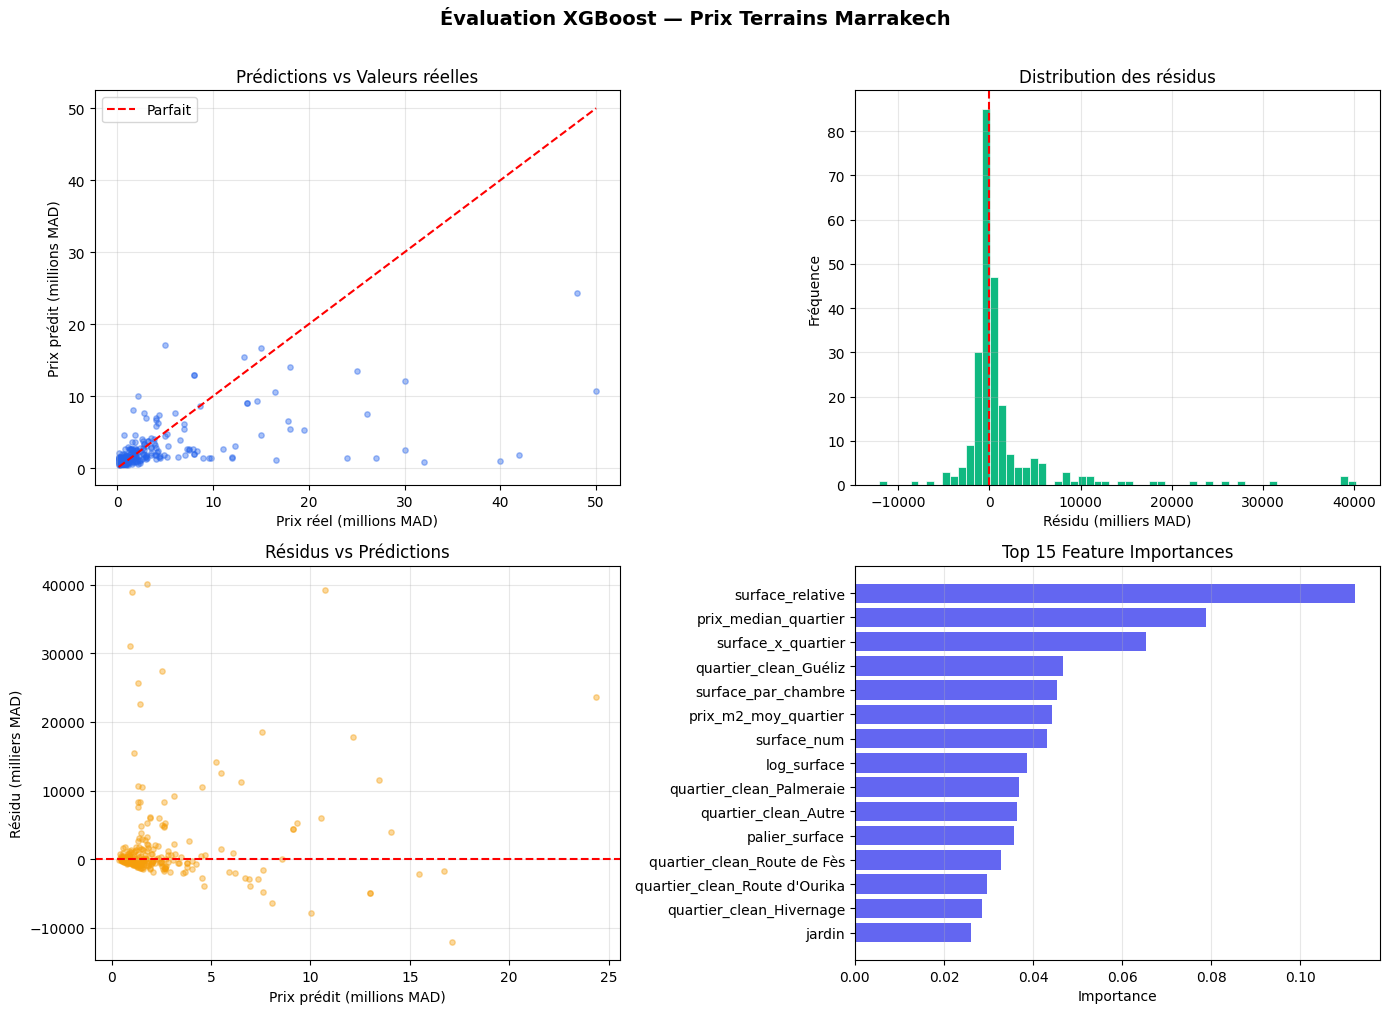

 Graphiques sauvegardés → terrain_model_evaluation.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Évaluation XGBoost — Prix Terrains Marrakech',
             fontsize=14, fontweight='bold', y=1.01)

residuals = y_true_mad - y_pred_mad

# 1. Prédictions vs Réel
ax = axes[0, 0]
ax.scatter(y_true_mad/1e6, y_pred_mad/1e6, alpha=0.4, s=15, color='#2563EB')
lims = [min(y_true_mad.min(), y_pred_mad.min())/1e6,
        max(y_true_mad.max(), y_pred_mad.max())/1e6]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Parfait')
ax.set_xlabel('Prix réel (millions MAD)'); ax.set_ylabel('Prix prédit (millions MAD)')
ax.set_title('Prédictions vs Valeurs réelles'); ax.legend(); ax.grid(True, alpha=0.3)

# 2. Distribution des résidus
ax = axes[0, 1]
ax.hist(residuals/1e3, bins=60, color='#10B981', edgecolor='white', linewidth=0.5)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Résidu (milliers MAD)'); ax.set_ylabel('Fréquence')
ax.set_title('Distribution des résidus'); ax.grid(True, alpha=0.3)

# 3. Résidus vs Prédictions
ax = axes[1, 0]
ax.scatter(y_pred_mad/1e6, residuals/1e3, alpha=0.4, s=15, color='#F59E0B')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Prix prédit (millions MAD)'); ax.set_ylabel('Résidu (milliers MAD)')
ax.set_title('Résidus vs Prédictions'); ax.grid(True, alpha=0.3)

# 4. Feature Importance
ax = axes[1, 1]
try:
    num_names = list(preprocessor.transformers_[0][2])
    bin_names = list(preprocessor.transformers_[1][2])
    cat_enc   = preprocessor.transformers_[2][1]
    cat_names = list(cat_enc.get_feature_names_out(CATEGORICAL_FEATURES))
    feature_names = num_names + bin_names + cat_names
except Exception:
    feature_names = [f'f{i}' for i in range(pipeline_final.named_steps['model'].n_features_in_)]

importances = pipeline_final.named_steps['model'].feature_importances_
top_n = min(15, len(feature_names))
idx   = np.argsort(importances)[-top_n:]
ax.barh([feature_names[i] for i in idx], importances[idx], color='#6366F1')
ax.set_xlabel('Importance'); ax.set_title(f'Top {top_n} Feature Importances')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('terrain_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Graphiques sauvegardés → terrain_model_evaluation.png')

## 12. Analyse des erreurs par quartier


In [13]:
erreur_pct = np.abs((y_true_mad - y_pred_mad) / y_true_mad) * 100

df_test = X_test.copy()
df_test['prix_reel']   = y_true_mad
df_test['prix_predit'] = y_pred_mad
df_test['erreur_pct']  = erreur_pct

print('=== MAPE par quartier ===')
print(df_test.groupby('quartier_clean')['erreur_pct']
      .agg(['mean','count']).sort_values('mean', ascending=False).round(1))

print('\n=== Distribution erreur % ===')
for seuil in [10, 20, 30, 50]:
    pct = (erreur_pct <= seuil).mean() * 100
    print(f'  Erreur <= {seuil:2d}% : {pct:.1f}% des cas')

=== MAPE par quartier ===
                      mean  count
quartier_clean                   
Hivernage            144.3      3
Autre                102.4    129
Route de Casablanca   98.6     31
Route d'Ourika        89.3     33
Guéliz                82.1      4
Route de Fès          80.1     25
Médina                71.2      4
Palmeraie             53.6      6
Targa                 26.3     14
Agdal                 25.8      1

=== Distribution erreur % ===
  Erreur <= 10% : 11.2% des cas
  Erreur <= 20% : 21.6% des cas
  Erreur <= 30% : 31.6% des cas
  Erreur <= 50% : 48.4% des cas


## 13. Sauvegarde du modèle et du dataset final


In [14]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

# Modèle
joblib.dump(pipeline_final, MODEL_PATH)
print(f' Modèle sauvegardé       → {MODEL_PATH}')

# Métadonnées
metadata = {
    'date'           : datetime.now().strftime('%Y-%m-%d'),
    'modele'         : 'XGBRegressor',
    'type_bien'      : 'terrain_vente',
    'n_lignes_train' : len(X_train),
    'n_lignes_test'  : len(X_test),
    'n_features'     : X_train.shape[1],
    'features'       : list(X_train.columns),
    'metriques_test' : {
        'R2'  : round(metrics_final['R²'], 4),
        'MAE' : round(metrics_final['MAE (MAD)'], 0),
        'RMSE': round(metrics_final['RMSE (MAD)'], 0),
        'MAPE': round(metrics_final['MAPE (%)'], 2),
        'CV_R2_mean': round(metrics_final['CV R² (mean)'], 4),
        'CV_R2_std' : round(metrics_final['CV R² (std)'], 4),
    },
    'best_params': study.best_params,
    'quartiers_connus': df['quartier_clean'].unique().tolist(),
    'filtres_cleaning': {
        'surface_min_m2': 50,
        'surface_max_m2': 500000,
        'prix_m2_min'   : 50,
        'prix_m2_max'   : 50000,
    },
}
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f' Métadonnées sauvegardées → {META_PATH}')

# Dataset nettoyé
df.to_csv(CLEAN_PATH, index=False)
print(f' Dataset propre sauvegardé → {CLEAN_PATH}')
print(f'   Shape finale : {df.shape}')

 Modèle sauvegardé       → ../../model_training/models/xgb_terrain_vente.pkl
 Métadonnées sauvegardées → ../../model_training/models/xgb_terrain_vente_metadata.json
 Dataset propre sauvegardé → ../../data/cleaned_data/vente/terrain_vente_final.csv
   Shape finale : (1247, 47)
